In [1]:
!nrnivmodl /home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism
from neuron import h
import plotly.graph_objects as go
import matplotlib.colors as mcolors
from neuron.units import ms, mV
import plotly.io as pio
from matplotlib import pyplot, cm
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import plotly
from neuron import clear_gui_callback
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from scipy.integrate import cumtrapz
from numpy.linalg import pinv, eig
import numpy as np
from multiprocessing import Pool
font2={'family':'Times New Roman',
'weight':'bold',
'size': 10}
# 自定义刻度标签显示格式

from matplotlib.ticker import FuncFormatter
def format_func(value, tick_number):
    return f'{value:.0f}'  # 将刻度值格式化为小数点后两位

def plot_curve(ax2,x,y,color='black',title='', linestyle='-',xlim=[0,100],dx=20,ylim=[0,10],dy=5.0, fontsize=10, alpha = 1.0, xlabel='Time/ms', ylabel = 'Frequency/Hz', label='',ynum_decimals =1):
    if color:
        ax2.plot(x,y,color=color,linewidth=2,linestyle=linestyle,alpha=alpha, label=label)
    else:
        ax2.plot(x,y,linewidth=2,alpha=alpha, linestyle=linestyle,label=label)
    ax2.set_xlabel(xlabel,font2)
    ax2.set_ylabel(ylabel,font2)
    
    # def format_funcx(value, tick_number, num_decimals=xnum_decimals):
    #     if num_decimals==0:
    #         return f'{value:.0f}'
    #     return f'{value:.{num_decimals}f}'

    def format_funcy(value, tick_number, num_decimals=ynum_decimals):
        if num_decimals==0:
          return f'{value:.0f}'
        return f'{value:.{num_decimals}f}'

    # if dx:
    #     ax2.set_xticks(np.arange(xlim[0], xlim[1] + dx, dx))
    #     ax2.set_xticklabels(ax2.get_xticks(), fontsize=fontsize, weight='bold')
    #     ax2.set_xlim([xlim[0], xlim[1]])
    #     ax2.xaxis.set_major_formatter(FuncFormatter(format_funcx))

    if dy:
        ax2.set_yticks(np.arange(ylim[0], ylim[1] + dy, dy))
        ax2.set_yticklabels(ax2.get_yticks(), fontsize=fontsize, weight='bold')
        ax2.set_ylim([ylim[0], ylim[1]])
        ax2.yaxis.set_major_formatter(FuncFormatter(format_funcy))
        
  
    if xlim:
       ax2.set_xticks(np.arange(xlim[0],xlim[1]+dx,dx))
       ax2.set_xticklabels(np.arange(xlim[0],xlim[1]+dx,dx),fontsize=10,weight='bold')
       ax2.set_xlim(xlim)
    # if ylim:
    #    ax2.set_yticks(np.arange(ylim[0],ylim[1]+dy,dy))
    #    ax2.set_yticklabels(np.arange(ylim[0],ylim[1]+dy,dy),fontsize=10,weight='bold')
    #    ax2.set_ylim(ylim)
    if title:
       ax2.set_title('{0}'.format(title),fontsize=12,weight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    if label:
       ax2.legend(loc='best',prop=font2,edgecolor='white')

h.load_file('nrngui.hoc')
h.load_file("import3d.hoc")

morphologyFilename = "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hoc"
biophysicalModelTemplateFilename = "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/PFCtemplate.hoc"

h.load_file(biophysicalModelTemplateFilename)



/home/wzl/anaconda/envs/neuron9/bin/nrnivmodl:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
INFO : Using neuron-nightly Package (Developer Version)
/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model
cfiles =
Mod files: "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism/ampain.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism/ampa.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism/cadynin.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism/cadyn.mod" "/home/w

--No graphics will be displayed.


1.0

# activate state

Opening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hoc
Denrite No!
1
1
1
0
0
1
1
1
1
1
0
0
0
0
1
1
1
1
1
1
1
1
0
0
0
0
0
1
1
1
0
1
1
1
1
1
1
1
1
0
1
1
1
1
1
1
0
0
0
0
0
0
1
1
1
0
0
0
1
1
1
0
0
1
0
1
1
1
-65.46373922700022


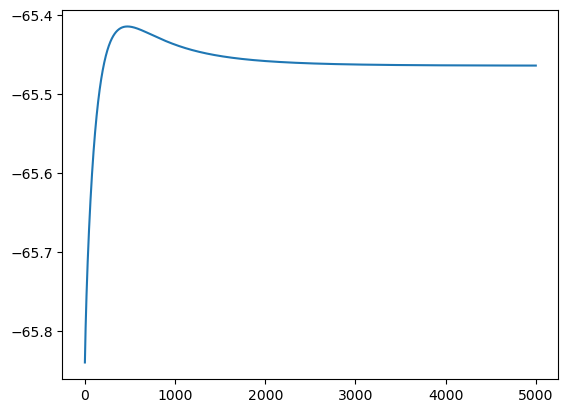

In [ ]:
neuron = h.FScell(morphologyFilename)
run_dt = 0.1
h.dt = run_dt
h.tstop = 500.
h.v_init = -65.84
    
recv = h.Vector().record(neuron.soma[0](0.5)._ref_v)

# Function to initialize the simulation
def initialize():
    h.t = 0
    h.finitialize(h.v_init)
    h.fcurrent()

# Function to integrate the simulation
def integrate():
    while h.t < h.tstop:
        h.fadvance()

# Function to run the simulation
def go():
    initialize()
    integrate()


go()
recv0 =  np.array(recv.to_python())
plt.plot(recv0)
print(recv0[5000])

# resting state: active: -65.46 mV


# passive state

Opening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hoc
Denrite No!
1
1
1
0
0
1
1
1
1
1
0
0
0
0
1
1
1
1
1
1
1
1
0
0
0
0
0
1
1
1
0
1
1
1
1
1
1
1
1
0
1
1
1
1
1
1
0
0
0
0
0
0
1
1
1
0
0
0
1
1
1
0
0
1
0
1
1
1
-65.00174375585364


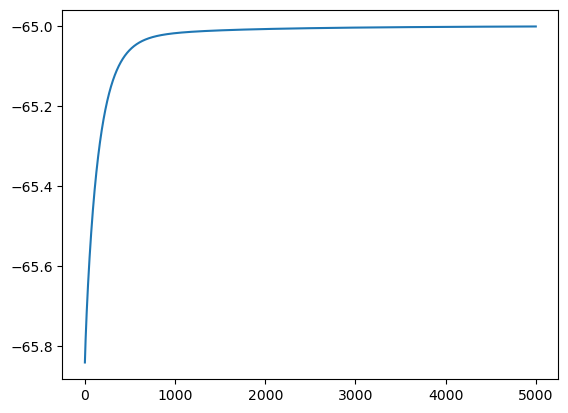

In [2]:
neuron = h.FScell(morphologyFilename)
for sec in h.allsec():
    # 检查 section 是否有主动离子通道
    if h.ismembrane("cal", sec=sec):
        sec.gcalbar_cal = 0.
    if h.ismembrane("calc", sec=sec):
        sec.gcabar_calc = 0.
    if h.ismembrane("calcb", sec=sec):
        sec.gcalbar_calcb = 0.
    if h.ismembrane("can", sec=sec):
        sec.gcabar_can = 0.
    if h.ismembrane("cancr", sec=sec):
        sec.gcabar_cancr = 0.
    if h.ismembrane("canin", sec=sec):
        sec.gcalbar_canin = 0.
    if h.ismembrane("car",sec=sec):
        sec.gcabar_car = 0.
    if h.ismembrane("cat",sec=sec):
        sec.gcatbar_cat = 0.
    if h.ismembrane("catcb",sec=sec):
        sec.gcatbar_catcb = 0.
    if h.ismembrane("h",sec=sec):
        sec.gbar_h = 0.
    if h.ismembrane("hcb",sec=sec):
        sec.gbar_hcb = 0.
    if h.ismembrane("hin",sec=sec):
        sec.gbar_hin = 0.
    if h.ismembrane("ican",sec=sec):
        sec.gbar_ican = 0.
    if h.ismembrane("iCcb",sec=sec):
        sec.gkcbar_iCcb = 0.
    if h.ismembrane("iCcr",sec=sec):
        sec.gkcbar_iCcr = 0.
    if h.ismembrane("iCin",sec=sec):
        sec.gkcbar_iCin = 0.
    if h.ismembrane("IKs",sec=sec):
        sec.gKsbar_IKs = 0.  
    if h.ismembrane("IKscb",sec=sec):
        sec.gKsbar_IKscb = 0.
    if h.ismembrane("IKscr", sec=sec):
        sec.gKsbar_IKscr = 0.
    if h.ismembrane("IKsin", sec=sec):
        sec.gKsbar_IKsin = 0.
    if h.ismembrane("kad", sec=sec):
        sec.gkabar_kad = 0.
    if h.ismembrane("kadcr", sec=sec):
        sec.gkabar_kadcr = 0.
    if h.ismembrane("kadin",sec=sec):
        sec.gkabar_kadin = 0.
    if h.ismembrane("kap",sec=sec):
        sec.gkabar_kap = 0.
    if h.ismembrane("kapcb",sec=sec):
        sec.gkabar_kapcb = 0.
    if h.ismembrane("kapin",sec=sec):
        sec.gkabar_kapin = 0.
    if h.ismembrane("kca",sec=sec):
        sec.gbar_kca = 0.
    if h.ismembrane("kcain",sec=sec):
        sec.gbar_kcain = 0.
    if h.ismembrane("iC",sec=sec):
        sec.gkcbar_iC = 0.
    if h.ismembrane("kctin",sec=sec):
        sec.gkcbar_kctin = 0.
    if h.ismembrane("kdr",sec=sec):
        sec.gkdrbar_kdr = 0.
    if h.ismembrane("kdrcb",sec=sec):
        sec.gkdrbar_kdrcb = 0.
    if h.ismembrane("kdrcr",sec=sec):
        sec.gkdrbar_kdrcr = 0.
    if h.ismembrane("kdrin",sec=sec):
        sec.gkdrbar_kdrin = 0.
    if h.ismembrane("Naf",sec=sec):
        sec.gnafbar_Naf = 0.
    if h.ismembrane("Nafcb",sec=sec):
        sec.gnafbar_Nafcb = 0.
    if h.ismembrane("Nafcr",sec=sec):
        sec.gnafbar_Nafcr = 0.
    if h.ismembrane("Nafin",sec=sec):
        sec.gnafbar_Nafin = 0.
    if h.ismembrane("Nafx",sec=sec):
        sec.gnafbar_Nafx = 0.
    if h.ismembrane("Nap",sec=sec):
        sec.gnapbar_Nap = 0.
run_dt = 0.1
h.dt = run_dt
h.tstop = 500.
h.v_init = -65.84
    
recv = h.Vector().record(neuron.soma[0](0.5)._ref_v)

# Function to initialize the simulation
def initialize():
    h.t = 0
    h.finitialize(h.v_init)
    h.fcurrent()

# Function to integrate the simulation
def integrate():
    while h.t < h.tstop:
        h.fadvance()

# Function to run the simulation
def go():
    initialize()
    integrate()


go()
recv0 =  np.array(recv.to_python())
plt.plot(recv0)
print(recv0[5000])

# resting state: passive: -65. mV